### full pipeline

In [1]:
import os

os.chdir('..')
os.getcwd()

'c:\\Users\\chouybat\\repositories\\phm-101'

In [2]:
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from matplotlib import pyplot as plt

from phm_101.config.configs import ConfigLoader
from phm_101.data_pipeline.data_extractor import DataExtractor
from phm_101.data_pipeline.data_loader import DataLoader
from phm_101.data_pipeline.data_transformer import DataTransformer
from phm_101.data_types.enums import ImsChannel, Paradigm
from phm_101.detectors.forecasting import ForecastingDetector
from phm_101.detectors.reconstruction import ReconstructionDetector
from phm_101.ml_pipeline.eval_pipeline import Evaluator

load_dotenv()

CONFIG_PATH = Path(os.environ.get('CONFIG_PATH'))
RAW_SIGNALS_DIR = Path(os.environ.get('RAW_SIGNALS_DIR'))

c:\Users\chouybat\repositories\phm-101\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### load configs

In [3]:
config_loader = ConfigLoader()

config = config_loader.load_config(path=CONFIG_PATH)

### data pipeline

In [4]:
data_extractor = DataExtractor(raw_signals_dir=RAW_SIGNALS_DIR)

channel_data = data_extractor.load(channel=ImsChannel(config.data_config.channel))

2026-08-29 18:25:28.522 | INFO     | phm_101.data_pipeline.data_extractor:load:52 - Loading IMS raw signals from parquet file for channel ImsChannel.T2B1
2026-08-29 18:25:28.627 | INFO     | phm_101.data_pipeline.data_extractor:load:80 - Terminated loading IMS raw signals from parquet file for channel ImsChannel.T2B1


In [5]:
data_transformer = DataTransformer(data_config=config.data_config)

data_splitted = data_transformer.train_test_split(data=channel_data)
data_transformer.fit(data=data_splitted.train)

normalized_train_data = data_transformer.transform(data=data_splitted.train)
normalized_val_data = data_transformer.transform(data=data_splitted.val)
normalized_test_data = data_transformer.transform(data=data_splitted.test)


2026-08-29 18:25:28.634 | INFO     | phm_101.data_pipeline.data_transformer:train_test_split:38 - Split ImsChannel.T2B1: 447 train, 111 val, 424 test
2026-08-29 18:25:28.653 | INFO     | phm_101.data_pipeline.data_transformer:fit:55 - Fitted mean=-0.001966 std=0.077178


In [6]:
data_loaders = DataLoader(
    window_size=config.data_config.window_size,
    hop=config.data_config.hop,
    num_workers = config.data_config.num_workers,
    pin_memory = True,
    seed=config.data_config.seed,
)

train_loader = data_loaders.get_dataloader(data=normalized_train_data, batch_size=config.data_config.batch_size, train=True)
val_loader = data_loaders.get_dataloader(data=normalized_val_data, batch_size=config.data_config.batch_size, train=True)
test_loader = data_loaders.get_dataloader(data=normalized_test_data, batch_size=config.data_config.batch_size, train=False)

2026-08-29 18:25:28.688 | INFO     | phm_101.data_pipeline.data_loader:get_dataloader:104 - Built train loader for ImsChannel.T2B1: 4470 windows
2026-08-29 18:25:28.690 | INFO     | phm_101.data_pipeline.data_loader:get_dataloader:104 - Built train loader for ImsChannel.T2B1: 1110 windows
2026-08-29 18:25:28.690 | INFO     | phm_101.data_pipeline.data_loader:get_dataloader:104 - Built eval loader for ImsChannel.T2B1: 4240 windows


### model detector

In [7]:
if config.model_config.paradigm is Paradigm.FORECASTING:

    detector = ForecastingDetector(
        model_config=config.model_config,
        data_config=config.data_config,
        train_config=config.training_config,
    )
else:
    detector = ReconstructionDetector(
        model_config=config.model_config,
        data_config=config.data_config,
        train_config=config.training_config,
    )

### train

2026-08-29 18:25:31.524 | INFO     | phm_101.ml_pipeline.train_pipeline:train:105 - Start training for 30 epochs using loss function: MSELoss, and optimizer: AdamW
training: 100%|██████████| 30/30 [00:04<00:00,  6.09it/s]
2026-08-29 18:25:36.454 | INFO     | phm_101.ml_pipeline.train_pipeline:train:146 - Best validation loss: 0.857993


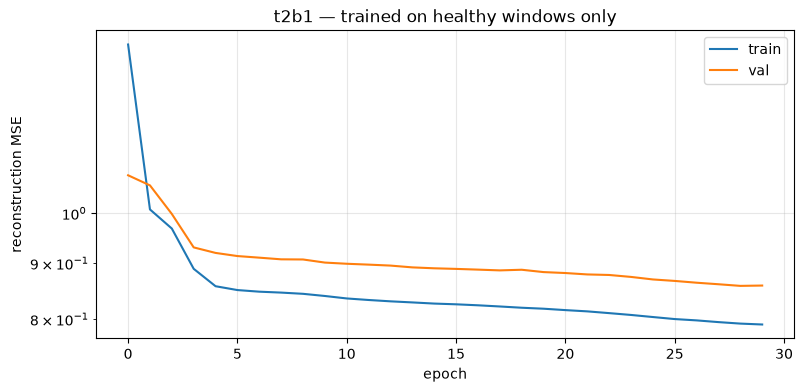

In [8]:
history = detector.fit(train_loader=train_loader, val_loader=val_loader)

plt.figure(figsize=(9, 4))
plt.plot(history.train_losses, label='train')
plt.plot(history.val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('reconstruction MSE')
plt.yscale('log')
plt.title(f'{config.data_config.channel} — trained on healthy windows only')
plt.legend()
plt.grid(alpha=0.3)

### evaluate

In [ ]:
evaluator = Evaluator(eval_config=config.evaluation_config, detector=detector, val_dataloader=val_loader, test_dataloader=test_loader)
result = evaluator.evaluate()


2026-08-29 18:25:37.416 | INFO     | phm_101.ml_pipeline.eval_pipeline:evaluate:42 - Evaluation: Metrics(accuracy=np.float64(0.6792452830188679), precision=np.float64(0.6730769230769231), recall=np.float64(1.0), fpr=np.float64(0.9444444444444444), tpr=np.float64(1.0), auroc=0.9649305555555556)


,value
0,Metrics(accuracy=np.float64(0.6792452830188679...
